# Function 5: Yield in a Chemical Reaction
This time you are trying to optimise another four-dimensional black-box. It corresponds to the yield of a chemical process after processing in some factory. This type of process tends to be unimodal. Try to find the combination of chemicals that maximizes the yield!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

In [2]:
def load_inputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    # Make the file a proper list of lists
    content = "[" + content.replace("]\n[", "],[") + "]"

    # Safe eval with restricted globals
    return eval(content, {"array": np.array})


def load_outputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    content = "[" + content.replace("]\n[", "],[") + "]"

    return eval(content, {"np": np})


def get_input_points(function_number, file_path="../inputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_inputs(file_path)
    index = function_number - 1

    inputs = [dataset[index] for dataset in data]
    return np.array(inputs)


def get_output_points(function_number, file_path="../outputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_outputs(file_path)
    index = function_number - 1

    outputs = [row[index] for row in data]
    return np.array(outputs)

# Load inputs
X = np.load(r'initial_inputs.npy')
y = np.load(r'initial_outputs.npy')


# Get input and outputs from submissions
inputs_array = get_input_points(5)
outputs_array = get_output_points(5)


# Append inputs_f1_array to X
X = np.vstack((X, inputs_array))

# Append outputs_f1_array to Y
y = np.hstack((y, outputs_array))

print("New shape of X:", X.shape)
print("New shape of Y:", y.shape)

New shape of X: (27, 4)
New shape of Y: (27,)


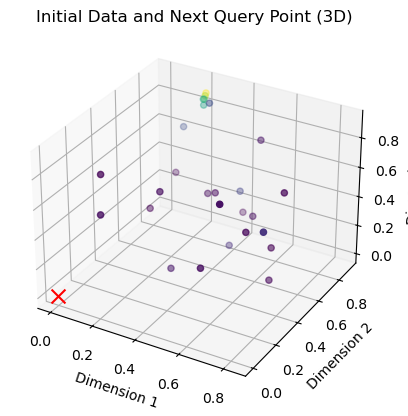

Next Query Point: 0.000000-0.000000-0.000000-0.530612


In [3]:
# Instantiate GPR model
gpr = GaussianProcessRegressor()
gpr.fit(X, y)

# Define grid of points
x1 = np.linspace(0, 1, 50)
x2 = np.linspace(0, 1, 50)
x3 = np.linspace(0, 1, 50)
x4 = np.linspace(0, 1, 50)
X_grid = np.array(np.meshgrid(x1, x2, x3, x4)).reshape(4, -1).T

# Predict with GPR
mean, std = gpr.predict(X, return_std=True)

# Calculate UCB
exploration_factor = 1.96
ucb = mean + exploration_factor * std

# Select next query point
next_query_index = np.argmax(ucb)
next_query = X_grid[next_query_index]

# Visualization
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2],  c=y, cmap='viridis')
ax.scatter(next_query[0], next_query[1], next_query[2], marker='x', color='red', s=100)
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_zlabel("Dimension 3")

ax.set_title("Initial Data and Next Query Point (3D)")
plt.show()

# Format the next query point
formatted_next_query = f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}"
print("Next Query Point:", formatted_next_query)